In [1]:
import pandas as pd
import numpy as np

np.random.seed(42)

n = 1000

diagnoses = [
    "Knee Osteoarthritis",
    "Low Back Pain",
    "Neck Pain",
    "Stroke",
    "Shoulder Pain",
    "Cervical Spondylosis",
    "Post Fracture"
]

treatments = [
    "Therapeutic Exercise",
    "Manual Therapy",
    "Gait Training",
    "Electrotherapy",
    "Strengthening",
    "ROM Exercises",
    "Balance Training"
]

departments = [
    "Orthopaedics",
    "Neurology",
    "Musculoskeletal",
    "Rehabilitation"
]

outcomes = [
    "Improved",
    "Partially Improved",
    "No Significant Change"
]

df_project = pd.DataFrame({
    "Patient_ID": range(1001, 2001),
    "Age": np.random.randint(18, 86, n),
    "Gender": np.random.choice(
        ["Female", "Male"], n, p=[0.52, 0.48]
    ),
    "Diagnosis": np.random.choice(diagnoses, n),
    "Pain": np.round(np.random.uniform(1, 10, n), 1),
    "Visit_Date": pd.to_datetime(
        np.random.choice(
            pd.date_range("2025-01-01", "2026-09-30"),
            n
        )
    ),
    "Treatment": np.random.choice(treatments, n),
    "Outcome": np.random.choice(
        outcomes, n, p=[0.58, 0.30, 0.12]
    ),
    "Comorbidity": np.random.choice(
        ["None", "Diabetes", "Hypertension",
         "Diabetes + Hypertension"],
        n,
        p=[0.55, 0.18, 0.17, 0.10]
    ),
    "Length_of_Treatment_Days": np.random.randint(7, 91, n),
    "Department": np.random.choice(departments, n)
})

df_project.head()

,Patient_ID,Age,Gender,Diagnosis,Pain,Visit_Date,Treatment,Outcome,Comorbidity,Length_of_Treatment_Days,Department
0,1001,69,Male,Post Fracture,6.1,2025-12-06,Strengthening,Partially Improved,None,34,Musculoskeletal
1,1002,32,Male,Stroke,5.0,2026-09-20,Therapeutic Exercise,Improved,None,43,Rehabilitation
2,1003,78,Female,Shoulder Pain,6.5,2026-03-15,Balance Training,Improved,Diabetes,71,Orthopaedics
3,1004,38,Female,Cervical Spondylosis,9.3,2025-05-24,Manual Therapy,Partially Improved,None,80,Orthopaedics
4,1005,41,Male,Neck Pain,4.3,2026-06-03,Manual Therapy,Improved,Diabetes + Hypertension,61,Rehabilitation


In [2]:
df_project.shape

(1000, 11)

In [3]:
df_project.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   Patient_ID                1000 non-null   int64         
 1   Age                       1000 non-null   int64         
 2   Gender                    1000 non-null   object        
 3   Diagnosis                 1000 non-null   object        
 4   Pain                      1000 non-null   float64       
 5   Visit_Date                1000 non-null   datetime64[ns]
 6   Treatment                 1000 non-null   object        
 7   Outcome                   1000 non-null   object        
 8   Comorbidity               1000 non-null   object        
 9   Length_of_Treatment_Days  1000 non-null   int64         
 10  Department                1000 non-null   object        
dtypes: datetime64[ns](1), float64(1), int64(3), object(6)
memory usage: 86.1+ KB


In [4]:
df_project.isnull().sum()

,0
Patient_ID,0
Age,0
Gender,0
Diagnosis,0
Pain,0
Visit_Date,0
Treatment,0
Outcome,0
Comorbidity,0
Length_of_Treatment_Days,0


In [5]:
df_project["Age"].describe()

,Age
count,1000.000000
mean,51.040000
std,19.986191
min,18.000000
25%,34.000000
50%,51.000000
75%,69.000000
max,85.000000


In [6]:
df_project["Diagnosis"].value_counts()

,count
Diagnosis,
Stroke,164
Neck Pain,152
Cervical Spondylosis,146
Knee Osteoarthritis,146
Shoulder Pain,145
Post Fracture,127
Low Back Pain,120


In [7]:
df_project.groupby("Diagnosis")["Pain"].mean().sort_values(ascending=False)

,Pain
Diagnosis,
Stroke,5.799390
Low Back Pain,5.791667
Post Fracture,5.674803
Cervical Spondylosis,5.667808
Shoulder Pain,5.652414
Neck Pain,5.637500
Knee Osteoarthritis,5.462329


In [8]:
df_project["Gender"].value_counts()

,count
Gender,
Female,508
Male,492


In [9]:
df_project.groupby("Gender")["Pain"].mean()

,Pain
Gender,
Female,5.605315
Male,5.733333


In [10]:
df_project[df_project["Age"] >= 50].groupby("Diagnosis")["Pain"].mean().sort_values(ascending=False)

,Pain
Diagnosis,
Stroke,5.979012
Cervical Spondylosis,5.590667
Shoulder Pain,5.583951
Low Back Pain,5.535211
Neck Pain,5.498667
Post Fracture,5.429412
Knee Osteoarthritis,5.294667


In [11]:
df_project["Treatment"].value_counts()

,count
Treatment,
Balance Training,167
Manual Therapy,147
Therapeutic Exercise,144
ROM Exercises,144
Strengthening,142
Gait Training,139
Electrotherapy,117


In [12]:
df_project.groupby(["Treatment", "Outcome"]).size()

Treatment             Outcome              
Balance Training      Improved                 96
                      No Significant Change    23
                      Partially Improved       48
Electrotherapy        Improved                 63
                      No Significant Change    15
                      Partially Improved       39
Gait Training         Improved                 85
                      No Significant Change    15
                      Partially Improved       39
Manual Therapy        Improved                 92
                      No Significant Change    16
                      Partially Improved       39
ROM Exercises         Improved                 96
                      No Significant Change    13
                      Partially Improved       35
Strengthening         Improved                 71
                      No Significant Change    24
                      Partially Improved       47
Therapeutic Exercise  Improved                 82
                      No Significant Change    18
                      Partially Improved       44
dtype: int64

In [13]:
df_project.groupby("Treatment")["Outcome"].apply(
    lambda x: (x == "Improved").mean() * 100
).sort_values(ascending=False)

,Outcome
Treatment,
ROM Exercises,66.666667
Manual Therapy,62.585034
Gait Training,61.151079
Balance Training,57.485030
Therapeutic Exercise,56.944444
Electrotherapy,53.846154
Strengthening,50.000000


In [14]:
df_project.groupby(["Diagnosis", "Treatment"])["Outcome"].apply(
    lambda x: (x == "Improved").mean() * 100
).sort_values(ascending=False).head(10)

Diagnosis             Treatment     
Low Back Pain         Gait Training     88.235294
Shoulder Pain         Electrotherapy    80.000000
                      Manual Therapy    72.000000
Knee Osteoarthritis   Gait Training     71.428571
Low Back Pain         ROM Exercises     71.428571
Shoulder Pain         Gait Training     71.428571
Knee Osteoarthritis   ROM Exercises     70.833333
                      Manual Therapy    68.421053
Cervical Spondylosis  ROM Exercises     68.421053
Stroke                ROM Exercises     67.857143
Name: Outcome, dtype: float64

In [15]:
df_project["Month"] = df_project["Visit_Date"].dt.to_period("M")

df_project["Month"].value_counts().sort_index()

,count
Month,
2025-01,46
2025-02,36
2025-03,47
2025-04,47
2025-05,48
2025-06,41
2025-07,68
2025-08,48
2025-09,51


In [16]:
monthly_treatment_recovery = (
    df_project[df_project["Outcome"] == "Improved"]
    .groupby(["Month", "Treatment"])
    .size()
    .reset_index(name="Improved_Patients")
)

monthly_treatment_recovery.sort_values(
    ["Month", "Improved_Patients"],
    ascending=[True, False]
)

,Month,Treatment,Improved_Patients
3,2025-01,Manual Therapy,6
4,2025-01,ROM Exercises,6
5,2025-01,Strengthening,5
1,2025-01,Electrotherapy,4
6,2025-01,Therapeutic Exercise,3
...,...,...,...
146,2026-09,Therapeutic Exercise,5
141,2026-09,Electrotherapy,3
143,2026-09,Manual Therapy,2
145,2026-09,Strengthening,2


In [17]:
monthly_top_treatment = (
    monthly_treatment_recovery
    .sort_values(["Month", "Improved_Patients"], ascending=[True, False])
    .groupby("Month")
    .head(1)
)

monthly_top_treatment

,Month,Treatment,Improved_Patients
3,2025-01,Manual Therapy,6
7,2025-02,Balance Training,6
16,2025-03,Gait Training,6
25,2025-04,ROM Exercises,6
28,2025-05,Balance Training,9
38,2025-06,Manual Therapy,6
48,2025-07,Therapeutic Exercise,8
50,2025-08,Electrotherapy,6
56,2025-09,Balance Training,6
66,2025-10,Manual Therapy,6


In [18]:
may = df_project[
    (df_project["Month"] == "2025-05") &
    (df_project["Treatment"] == "Balance Training")
]

may["Outcome"].value_counts()

,count
Outcome,
Improved,9
Partially Improved,3


In [19]:
df_project.groupby(["Month", "Treatment"])["Outcome"].apply(
    lambda x: (x == "Improved").mean() * 100
).sort_values(ascending=False).head(10)

Month    Treatment           
2025-02  Manual Therapy          100.0
         Therapeutic Exercise    100.0
2025-05  ROM Exercises           100.0
2026-08  Balance Training        100.0
2026-04  Gait Training           100.0
2026-07  Manual Therapy          100.0
2026-06  Manual Therapy          100.0
2025-11  ROM Exercises           100.0
2026-07  Electrotherapy          100.0
2026-05  ROM Exercises            87.5
Name: Outcome, dtype: float64

In [20]:
df_project.groupby(["Month", "Treatment"]).agg(
    Total_Patients=("Outcome", "count"),
    Improved_Patients=("Outcome", lambda x: (x == "Improved").sum())
).sort_values("Improved_Patients", ascending=False).head(10)

Total_Patients  Improved_Patients
Month   Treatment                                              
2025-05 Balance Training                  12                  9
2026-05 Strengthening                     12                  9
2026-04 Strengthening                     11                  8
2025-07 Therapeutic Exercise              11                  8
2026-07 Manual Therapy                     8                  8
2025-12 Balance Training                  10                  7
2025-07 Gait Training                     12                  7
        Manual Therapy                    11                  7
2026-05 ROM Exercises                      8                  7
2026-03 Therapeutic Exercise               9                  7

In [21]:
df_project.groupby("Treatment").agg(
    Total_Patients=("Outcome", "count"),
    Improved_Patients=("Outcome", lambda x: (x == "Improved").sum())
).assign(
    Improvement_Rate=lambda x:
    x["Improved_Patients"] / x["Total_Patients"] * 100
).sort_values("Improvement_Rate", ascending=False)

,Total_Patients,Improved_Patients,Improvement_Rate
Treatment,,,
ROM Exercises,144,96,66.666667
Manual Therapy,147,92,62.585034
Gait Training,139,85,61.151079
Balance Training,167,96,57.485030
Therapeutic Exercise,144,82,56.944444
Electrotherapy,117,63,53.846154
Strengthening,142,71,50.000000


<Axes: title={'center': 'Observed Improvement Rate by Treatment'}, xlabel='Treatment', ylabel='Improvement Rate (%)'>

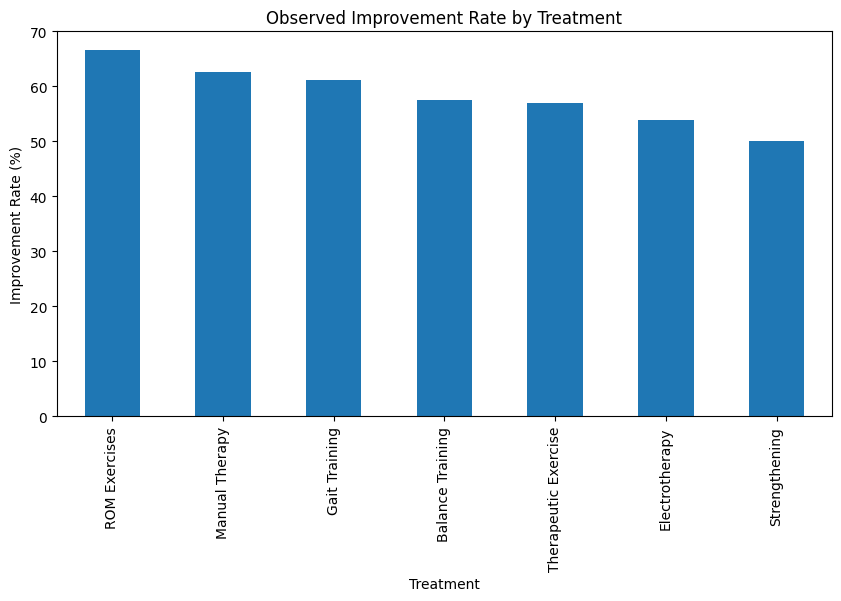

In [22]:
treatment_rate = df_project.groupby("Treatment")["Outcome"].apply(
    lambda x: (x == "Improved").mean() * 100
).sort_values(ascending=False)

treatment_rate.plot(
    kind="bar",
    title="Observed Improvement Rate by Treatment",
    ylabel="Improvement Rate (%)",
    xlabel="Treatment",
    figsize=(10,5)
)

<Axes: title={'center': 'Monthly Number of Improved Patients'}, xlabel='Month', ylabel='Improved Patients'>

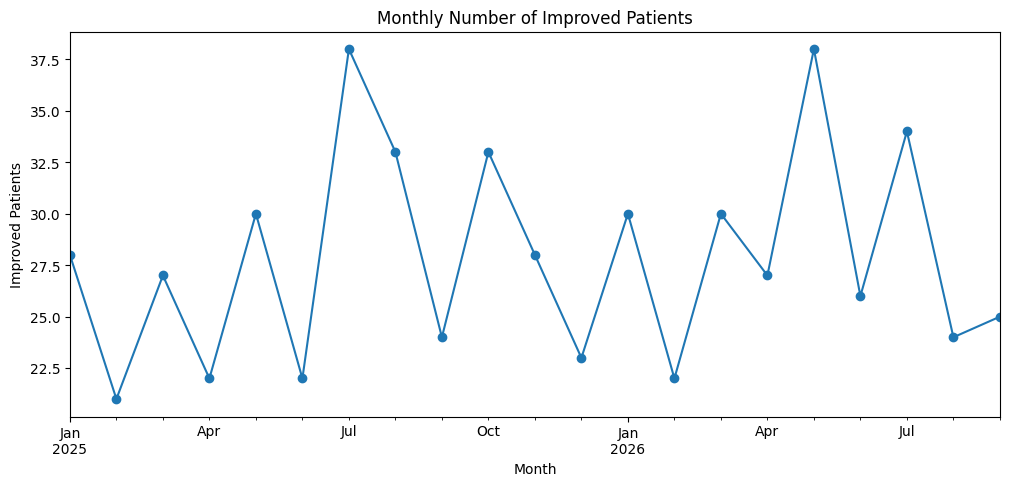

In [23]:
monthly_recovery = (
    df_project[df_project["Outcome"] == "Improved"]
    .groupby("Month")
    .size()
)

monthly_recovery.plot(
    kind="line",
    marker="o",
    title="Monthly Number of Improved Patients",
    ylabel="Improved Patients",
    xlabel="Month",
    figsize=(12,5)
)

<Axes: title={'center': 'Average Pain Score by Diagnosis'}, xlabel='Diagnosis', ylabel='Average Pain Score'>

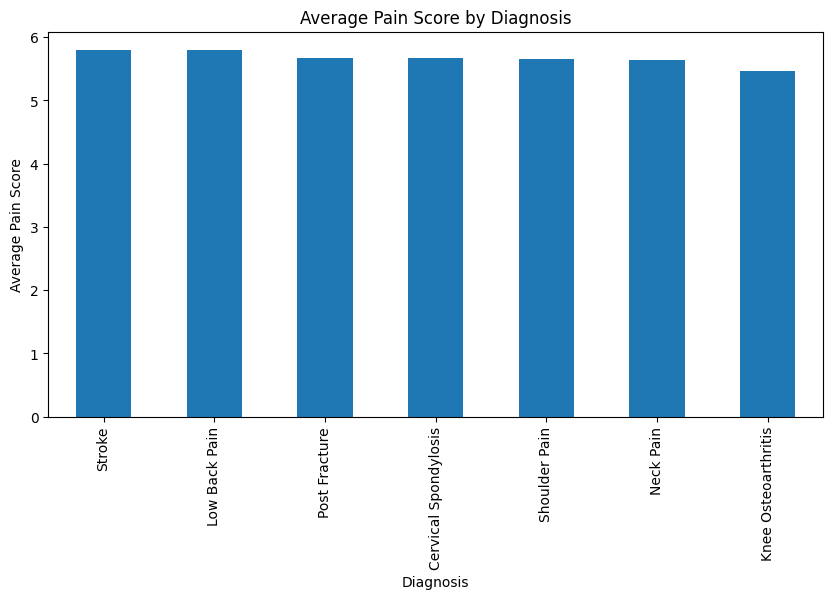

In [24]:
diagnosis_pain = (
    df_project.groupby("Diagnosis")["Pain"]
    .mean()
    .sort_values(ascending=False)
)

diagnosis_pain.plot(
    kind="bar",
    title="Average Pain Score by Diagnosis",
    ylabel="Average Pain Score",
    xlabel="Diagnosis",
    figsize=(10,5)
)

<Axes: title={'center': 'Patient Volume by Diagnosis'}, xlabel='Diagnosis', ylabel='Number of Patients'>

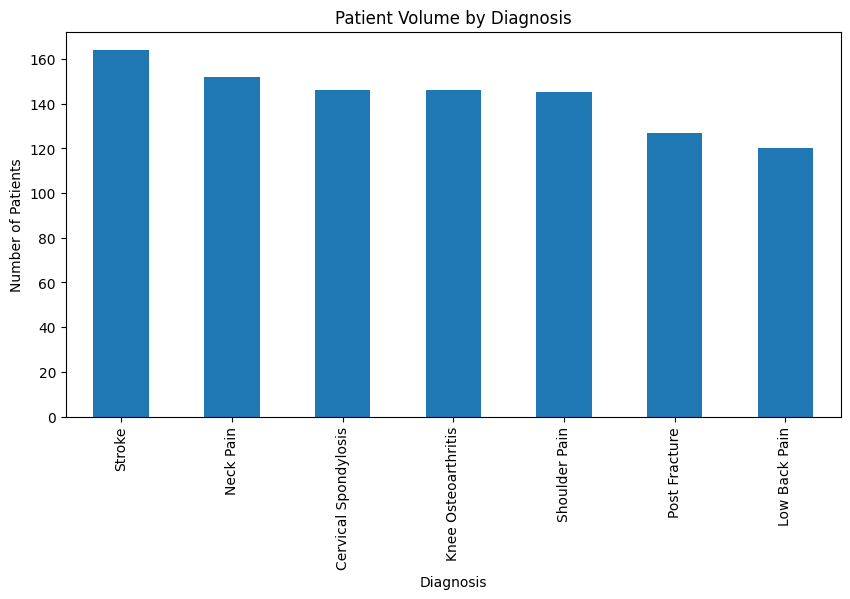

In [25]:
diagnosis_count = df_project["Diagnosis"].value_counts()

diagnosis_count.plot(
    kind="bar",
    title="Patient Volume by Diagnosis",
    ylabel="Number of Patients",
    xlabel="Diagnosis",
    figsize=(10,5)
)